# 区域电力负荷预测项目

## 一、研究目标

本项目目标是基于历史电力负荷及其时间特征，对未来时刻的电力负荷进行监督学习预测。由于电力负荷具有明显的时间依赖、日周期、周周期和阶段性波动，因此建模时必须按照时间顺序构建训练集、验证集和测试集。

## 二、建模流程

1. **读取原始数据**：确认时间列和目标变量存在，并将时间列解析为 `datetime` 类型。
2. **探索性分析**：观察负荷序列的整体变化、小时规律和星期规律。
3. **数据清洗**：处理缺失值、无穷值和异常值，尽量保留时间序列连续性。
4. **特征工程**：构造日历特征、周期编码、滞后特征、滚动统计特征和历史变化特征。
5. **时间顺序划分数据集**：训练集用于拟合模型，验证集用于选择模型和融合权重，测试集只用于最终评估。核心原则是：**时间序列任务中严格避免数据泄漏**。尤其是所有由目标变量衍生出的特征，都必须只使用预测时刻之前已经发生的数据。例如差分特征不能直接由当前真实值计算，而要先 `shift(1)` 再计算差分或滚动统计。
6. **训练多个模型**：包括基准模型、Ridge、XGBoost、LightGBM、CatBoost 和 LSTM。
7. **构建加权融合模型**：根据验证集表现筛选和加权多个模型。
8. **结果可视化与误差分析**：比较不同模型预测曲线、RMSE 柱状图、误差时间序列和误差分布。


In [1]:
# ============================================================
# 0. 项目配置与依赖导入
# ============================================================
# 这一部分集中管理路径、列名、随机种子、训练比例等参数。
# 这样做的好处是：后续如果更换数据集或目标变量，只需要改这里。

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# 可选模型依赖：如果本地没有安装某个包，程序不会直接崩溃，
# 而是会在对应模型单元中自动跳过。
# ------------------------------------------------------------
try:
    from xgboost import XGBRegressor
except Exception as e:
    XGBRegressor = None
    print(f"提示：XGBoost 未安装或无法导入，将跳过 XGBoost。原因：{e}")

try:
    from lightgbm import LGBMRegressor
except Exception as e:
    LGBMRegressor = None
    print(f"提示：LightGBM 未安装或无法导入，将跳过 LightGBM。原因：{e}")

try:
    from catboost import CatBoostRegressor
except Exception as e:
    CatBoostRegressor = None
    print(f"提示：CatBoost 未安装或无法导入，将跳过 CatBoost。原因：{e}")

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception as e:
    tf = None
    print(f"提示：TensorFlow/Keras 未安装或无法导入，将跳过 LSTM。原因：{e}")

# ------------------------------------------------------------
# 全局参数配置
# ------------------------------------------------------------
DATA_PATH = Path("continuous dataset.csv")  # 数据文件路径
DATETIME_COL = "datetime"                   # 时间列名称
TARGET_COL = "nat_demand"                  # 预测目标列：电力负荷

RANDOM_STATE = 42                            # 固定随机种子，便于复现实验结果
TRAIN_RATIO = 0.70                           # 前 70% 时间段作为训练集
VALID_RATIO = 0.15                           # 中间 15% 时间段作为验证集
LOOK_BACK = 24                               # LSTM 使用过去 24 个时间点预测下一个时间点

# Matplotlib 中文显示设置：如果电脑没有这些字体，会自动回退到默认字体。
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

warnings.filterwarnings("ignore")

print("基础配置已完成。")

基础配置已完成。


In [2]:
# ============================================================
# 1. 通用评估函数
# ============================================================
# 将 MAE、RMSE、MAPE 封装为函数，后续所有模型都使用同一套评估标准。
# 这样可以避免每个模型重复写评估代码，也能保证横向对比公平。


def safe_mape(y_true, y_pred):
    """
    计算 MAPE（平均绝对百分比误差）。

    注意：
    - 如果 y_true 中存在 0，直接除以 0 会导致无穷大或报错。
    - 因此这里会自动忽略 y_true == 0 的样本。
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    """
    返回常用回归指标：MAE、RMSE、MAPE。

    指标含义：
    - MAE：平均绝对误差，单位和目标变量一致，越小越好。
    - RMSE：均方根误差，对大误差更敏感，越小越好。
    - MAPE：百分比误差，便于理解相对误差，越小越好。
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = safe_mape(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE(%)": mape,
    }


# 用于保存不同模型的验证集、测试集预测结果。
# 后续会基于验证集误差计算融合权重。
valid_predictions = {}
test_predictions = {}
results = []


def register_model_result(model_name, y_valid, pred_valid, y_test, pred_test, valid_index, test_index):
    """
    统一登记模型结果。

    参数说明：
    - model_name：模型名称，例如 XGBoost、LightGBM。
    - y_valid / pred_valid：验证集真实值和预测值。
    - y_test / pred_test：测试集真实值和预测值。
    - valid_index / test_index：对应的时间索引，用于后续画图和对齐预测结果。
    """
    valid_predictions[model_name] = pd.Series(pred_valid, index=valid_index, name=model_name)
    test_predictions[model_name] = pd.Series(pred_test, index=test_index, name=model_name)

    valid_metrics = regression_metrics(y_valid, pred_valid)
    test_metrics = regression_metrics(y_test, pred_test)

    results.append({"Model": model_name, "Split": "Valid", **valid_metrics})
    results.append({"Model": model_name, "Split": "Test", **test_metrics})

    print(f"{model_name} 已完成：Valid RMSE = {valid_metrics['RMSE']:.4f}，Test RMSE = {test_metrics['RMSE']:.4f}")

## 评判指标说明

本项目使用 `MAE`、`RMSE` 和 `MAPE` 三个指标评价模型效果。三个指标从不同角度衡量预测误差，建议结合使用，而不是只看单一指标。

### 1. MAE：平均绝对误差

MAE 衡量预测值与真实值之间的平均绝对偏差，单位与原始负荷相同。它的含义直观，表示模型平均每个时间点大约预测偏离多少。MAE 越小，说明整体平均误差越低。

### 2. RMSE：均方根误差

RMSE 会对较大的误差给予更高惩罚，因此比 MAE 更关注峰值时段或异常波动时段的预测能力。对于电力负荷预测而言，高峰期预测偏差往往更重要，因此 RMSE 通常应作为主要比较指标之一。RMSE 越小，说明模型对大误差的控制能力越好。

### 3. MAPE：平均绝对百分比误差

MAPE 表示预测误差相对于真实值的百分比，便于从业务角度理解模型误差水平。例如 MAPE 为 1.5%，可以理解为平均预测偏差约为真实负荷的 1.5%。由于 MAPE 需要除以真实值，当真实值为 0 时会产生问题，因此代码中使用 `safe_mape` 自动跳过真实值为 0 的样本。

### 4. 模型选择原则

本 notebook 中，验证集主要用于模型筛选、模型比较和融合权重确定；测试集用于最终泛化能力评估。最终模型不应只依据验证集表现决定，而应综合测试集 MAE、RMSE、MAPE。若多个模型 MAE 接近，优先关注 RMSE 更低、误差峰值更小的模型。


In [3]:
# ============================================================
# 2. 数据加载
# ============================================================
# 时间序列任务中，时间列必须正确解析为 datetime 类型，且必须按时间升序排列。
# 这里还会检查关键列是否存在，避免后面运行到一半才报错。

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"没有找到数据文件：{DATA_PATH}\n"
        "请把 continuous dataset.csv 放到 notebook 同一目录，"
        "或者修改 DATA_PATH 为正确路径。"
    )

# 先读取原始数据，再单独解析时间列，便于给出更清楚的错误信息。
df_raw = pd.read_csv(DATA_PATH)

required_cols = {DATETIME_COL, TARGET_COL}
missing_cols = required_cols - set(df_raw.columns)
if missing_cols:
    raise ValueError(f"数据缺少必要列：{missing_cols}。请检查列名或修改 DATETIME_COL / TARGET_COL。")

# 将时间列转成 datetime；无法解析的时间会变成 NaT，后续会删除。
df_raw[DATETIME_COL] = pd.to_datetime(df_raw[DATETIME_COL], errors="coerce")
df_raw = df_raw.dropna(subset=[DATETIME_COL])

# 按时间升序排列，并删除重复时间点。
# 如果同一个时间点有多条记录，这里保留最后一条；也可以根据业务需要改成取平均。
df_raw = (
    df_raw
    .sort_values(DATETIME_COL)
    .drop_duplicates(subset=[DATETIME_COL], keep="last")
    .reset_index(drop=True)
)

print("数据加载完成。")
print(f"数据形状：{df_raw.shape}")
print(f"时间范围：{df_raw[DATETIME_COL].min()} 至 {df_raw[DATETIME_COL].max()}")
display(df_raw.head())

数据加载完成。
数据形状：(48048, 17)
时间范围：2015-01-03 01:00:00 至 2020-06-27 00:00:00


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


目标变量描述统计：


count    48048.000000
mean      1182.868647
std        192.068896
min         85.192500
25%       1020.056900
50%       1168.427700
75%       1327.563950
max       1754.882000
Name: nat_demand, dtype: float64

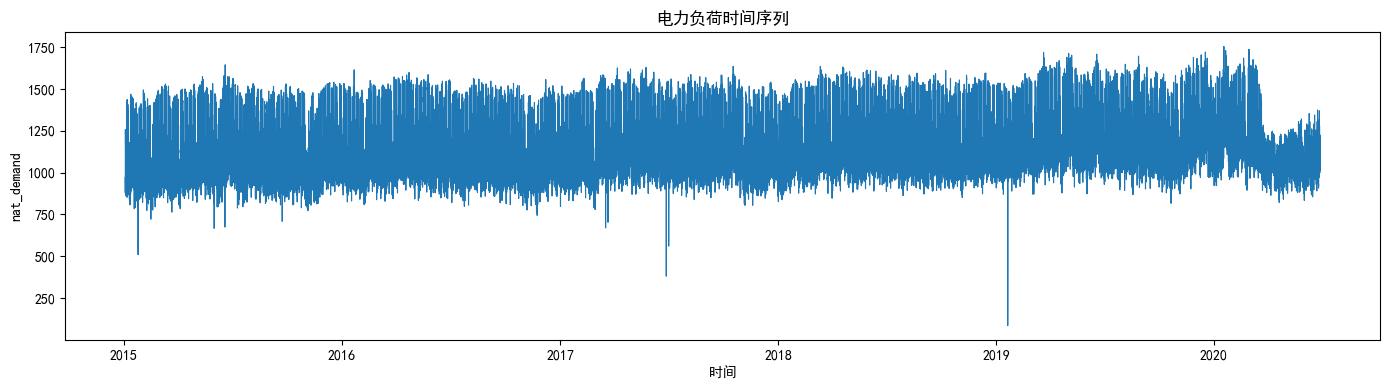

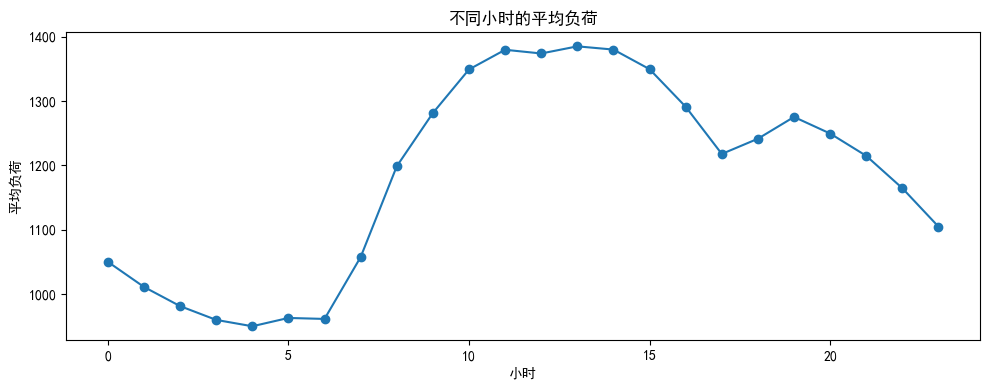

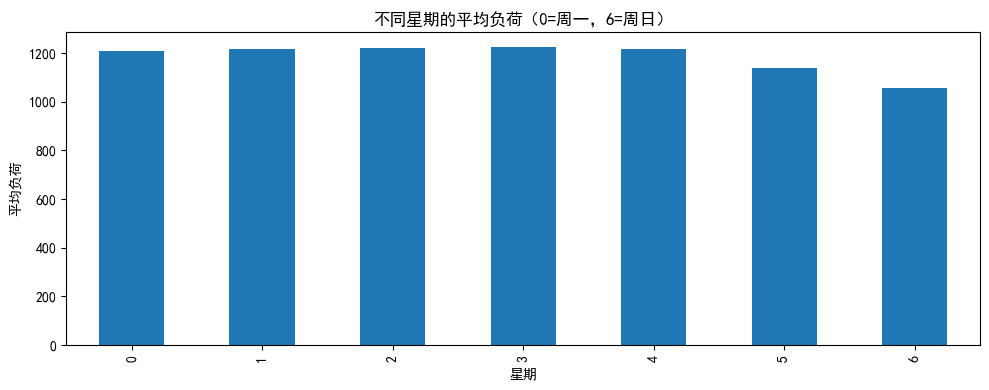

In [4]:
# ============================================================
# 3. 初步探索性分析（EDA）
# ============================================================
# EDA 的目的不是建模，而是先观察数据的整体规律：
# - 是否存在明显趋势？
# - 是否有日周期、周周期？
# - 是否存在异常尖峰或缺失？

print("目标变量描述统计：")
display(df_raw[TARGET_COL].describe())

# 3.1 整体负荷时间序列图
plt.figure(figsize=(14, 4))
plt.plot(df_raw[DATETIME_COL], df_raw[TARGET_COL], linewidth=0.8)
plt.title("电力负荷时间序列")
plt.xlabel("时间")
plt.ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

# 3.2 小时维度规律：观察一天中不同小时的平均负荷
eda_df = df_raw[[DATETIME_COL, TARGET_COL]].copy()
eda_df["hour"] = eda_df[DATETIME_COL].dt.hour

plt.figure(figsize=(10, 4))
eda_df.groupby("hour")[TARGET_COL].mean().plot(marker="o")
plt.title("不同小时的平均负荷")
plt.xlabel("小时")
plt.ylabel("平均负荷")
plt.tight_layout()
plt.show()

# 3.3 星期维度规律：观察工作日和周末是否不同
eda_df["dayofweek"] = eda_df[DATETIME_COL].dt.dayofweek

plt.figure(figsize=(10, 4))
eda_df.groupby("dayofweek")[TARGET_COL].mean().plot(kind="bar")
plt.title("不同星期的平均负荷（0=周一，6=周日）")
plt.xlabel("星期")
plt.ylabel("平均负荷")
plt.tight_layout()
plt.show()

## EDA 可视化解释

本节的三张图主要用于理解负荷数据的时间规律，而不是直接判断模型优劣。

### 1. 电力负荷时间序列图

该图展示目标变量随时间变化的整体轨迹。观察重点包括：是否存在长期趋势、季节性变化、周期波动、异常尖峰或明显断点。如果负荷曲线具有稳定的周期性，说明滞后特征和周期特征会对预测有帮助；如果存在突发尖峰，则后续误差分析中也需要重点关注这些时段。

### 2. 不同小时的平均负荷

该图用于观察日内周期规律。若不同小时的平均负荷差异明显，说明小时特征、`hour_sin` 和 `hour_cos` 等周期编码具有建模价值。通常电力负荷会在一天中的某些时段形成高峰，而夜间或低活动时段相对较低。

### 3. 不同星期的平均负荷

该图用于观察周内规律，即工作日与周末是否存在负荷差异。如果星期维度差异明显，则 `dayofweek`、`is_weekend`、`dow_sin` 和 `dow_cos` 等特征可以帮助模型识别周周期变化。


In [5]:
# ============================================================
# 4. 数据清洗
# ============================================================
# 优化点说明：
# 1. 原代码使用 fillna(method='ffill')，新版 pandas 中更推荐直接写 ffill()。
# 2. 原代码遇到异常值时直接删除整行，这可能破坏时间序列的连续性。
# 3. 这里改为对目标变量进行 IQR 裁剪（clip），既降低极端值影响，又保留时间点。


df = df_raw.copy()

# 将正无穷、负无穷统一替换成缺失值，便于后续处理。
df = df.replace([np.inf, -np.inf], np.nan)

# 将时间列设为索引，方便使用基于时间的插值方法。
df = df.set_index(DATETIME_COL).sort_index()

# 数值列：优先使用 time interpolation 按时间插值，再前向/后向填充兜底。
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df[col] = df[col].interpolate(method="time").ffill().bfill()

# 非数值列：使用前向/后向填充，通常适合节假日、类别标记等字段。
non_numeric_cols = [col for col in df.columns if col not in numeric_cols]
for col in non_numeric_cols:
    df[col] = df[col].ffill().bfill()

# IQR 异常值裁剪：只对预测目标做裁剪，不随意改变其他解释变量。
q1 = df[TARGET_COL].quantile(0.25)
q3 = df[TARGET_COL].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df[TARGET_COL] = df[TARGET_COL].clip(lower=lower_bound, upper=upper_bound)

# 恢复 datetime 为普通列，便于后续特征工程。
df = df.reset_index()

print("数据清洗完成。")
print(f"清洗后缺失值总数：{df.isna().sum().sum()}")
print(f"目标变量裁剪范围：[{lower_bound:.2f}, {upper_bound:.2f}]")
display(df.head())

数据清洗完成。
清洗后缺失值总数：0
目标变量裁剪范围：[558.80, 1788.82]


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


## 数据清洗说明

本节清洗策略强调两个目标：第一，尽量保留时间序列的连续性；第二，降低异常值和缺失值对模型的干扰。

对于缺失值，代码先按时间进行插值，再使用前向填充和后向填充作为兜底。这样做比直接删除缺失行更适合时间序列任务，因为删除行可能破坏相邻时间点之间的连续关系。

对于异常值，代码采用 IQR 裁剪方式，而不是直接删除异常行。裁剪会把极端值限制在合理范围内，既保留该时间点，又减少极端负荷对模型训练的影响。这对于电力负荷预测尤其重要，因为异常尖峰可能来自特殊事件、数据采集异常或短期波动。


In [6]:
# ============================================================
# 5. 特征工程
# ============================================================
# 时间序列预测的关键在于构造“历史信息”和“周期信息”。
# 本单元会构造三类特征：
# 1. 时间日历特征：小时、星期、月份、是否周末等。
# 2. 周期编码特征：用 sin/cos 表达小时、星期、月份的周期性。
# 3. 滞后与滚动统计特征：使用过去负荷帮助预测未来负荷。
#
# 重要防泄漏原则：
# - 当前时刻 t 的特征只能使用 t 之前已经知道的信息。
# - 目标变量 nat_demand 的任何衍生特征都必须先 shift(1)，再计算统计量。
# - 不能写 result[target_col].diff(1)，因为它等于 y_t - y_{t-1}，包含当前真实值 y_t。
#   如果模型同时拿到 lag_1 和 diff_1，就可以近似还原 y_t，导致 Ridge 等模型分数异常好。


def add_calendar_features(data, datetime_col):
    """添加时间日历特征和周期编码特征。"""
    result = data.copy()
    dt = result[datetime_col]

    # 基础时间特征
    result["hour"] = dt.dt.hour
    result["dayofweek"] = dt.dt.dayofweek
    result["dayofmonth"] = dt.dt.day
    result["dayofyear"] = dt.dt.dayofyear
    result["weekofyear"] = dt.dt.isocalendar().week.astype(int)
    result["month"] = dt.dt.month
    result["quarter"] = dt.dt.quarter
    result["is_weekend"] = (result["dayofweek"] >= 5).astype(int)

    # 周期编码：避免模型误以为 23 点和 0 点距离很远。
    result["hour_sin"] = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"] = np.cos(2 * np.pi * result["hour"] / 24)

    result["dow_sin"] = np.sin(2 * np.pi * result["dayofweek"] / 7)
    result["dow_cos"] = np.cos(2 * np.pi * result["dayofweek"] / 7)

    result["month_sin"] = np.sin(2 * np.pi * result["month"] / 12)
    result["month_cos"] = np.cos(2 * np.pi * result["month"] / 12)

    return result


def add_lag_and_rolling_features(data, target_col):
    """添加滞后特征和滚动统计特征。"""
    result = data.copy()

    # 常见滞后：
    # - 1、2、3：短期惯性
    # - 24、48、72：前 1/2/3 天同一时间点
    # - 168：前一周同一时间点，小时级数据常用
    lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
    for lag in lags:
        result[f"{target_col}_lag_{lag}"] = result[target_col].shift(lag)

    # 所有目标变量衍生特征都从 history 开始计算。
    # history 在 t 时刻对应 y_{t-1}，因此不会泄漏当前真实值 y_t。
    history = result[target_col].shift(1)

    # 滚动窗口统计：先 shift(1)，确保只看历史，不看当前真实值。
    windows = [6, 12, 24, 48, 168]
    for window in windows:
        result[f"{target_col}_roll_mean_{window}"] = history.rolling(window=window, min_periods=window).mean()
        result[f"{target_col}_roll_std_{window}"] = history.rolling(window=window, min_periods=window).std()
        result[f"{target_col}_roll_max_{window}"] = history.rolling(window=window, min_periods=window).max()
        result[f"{target_col}_roll_min_{window}"] = history.rolling(window=window, min_periods=window).min()

    # 变化率特征：必须基于 history 计算。
    # 正确含义：
    # - diff_1 在 t 时刻表示 y_{t-1} - y_{t-2}
    # - diff_24 在 t 时刻表示 y_{t-1} - y_{t-25}
    # 这样模型只能看到“预测点之前”的变化趋势，不会看到当前真实值。
    result[f"{target_col}_diff_1"] = history.diff(1)
    result[f"{target_col}_diff_24"] = history.diff(24)

    return result


# 执行特征工程
df_feat = add_calendar_features(df, DATETIME_COL)
df_feat = add_lag_and_rolling_features(df_feat, TARGET_COL)

# 类别变量处理：将文本/类别列转为 one-hot，保证 sklearn 模型可以使用。
# 注意：datetime 和目标列不能做 one-hot。
categorical_cols = [
    col for col in df_feat.select_dtypes(include=["object", "category", "bool"]).columns
    if col not in [DATETIME_COL, TARGET_COL]
]

if categorical_cols:
    df_feat = pd.get_dummies(df_feat, columns=categorical_cols, drop_first=True)

# 由于 lag/rolling/diff 会在前若干行产生缺失值，这些行没有足够历史信息，直接删除。
df_feat = df_feat.dropna().reset_index(drop=True)

print("特征工程完成。")
print(f"特征工程后数据量：{df_feat.shape}")
print("防泄漏处理：diff 特征已改为基于 shift(1) 后的历史序列计算。")



特征工程完成。
特征工程后数据量：(47880, 62)
防泄漏处理：diff 特征已改为基于 shift(1) 后的历史序列计算。


## 特征工程说明

本节是整个预测任务中最关键的部分。电力负荷预测本质上依赖两类信息：一类是时间本身带来的周期规律，另一类是历史负荷对当前负荷的惯性影响。

### 1. 日历特征

小时、星期、月份、季度、是否周末等特征用于帮助模型识别不同时间位置下的负荷水平差异。例如，同一天中的早晚高峰、工作日与周末差异，都可以通过这些变量表达。

### 2. 周期编码特征

时间变量具有循环特征，例如 23 点和 0 点在数值上相差 23，但在时间上实际上是相邻的。使用 `sin` / `cos` 编码可以让模型更自然地理解这种周期关系。

### 3. 滞后特征

滞后特征直接使用历史负荷值，例如前 1 小时、前 24 小时、前 168 小时的负荷。对于小时级电力负荷数据，`lag_24` 通常反映“昨天同一时刻”的规律，`lag_168` 通常反映“上周同一时刻”的规律。

### 4. 滚动统计特征

滚动均值、标准差、最大值和最小值可以表达过去一段时间的平均水平、波动程度和极端范围。这些特征能帮助模型判断当前负荷处于平稳阶段还是剧烈波动阶段。

### 5. 防止数据泄漏

代码中特别注意：所有由目标变量产生的统计特征都基于 `shift(1)` 后的历史序列计算。这意味着预测时刻 `t` 的特征只包含 `t` 之前的信息，不包含当前真实值 `y_t`。这一点对时间序列预测非常重要，否则模型可能“偷看答案”，导致验证和测试结果虚高。


In [7]:
# ============================================================
# 6. 时间序列数据划分
# ============================================================
# 时间序列不能随机打乱，否则会把未来信息混入训练集。
# 因此这里使用按时间顺序切分：
# - 训练集：最早的 70%
# - 验证集：中间的 15%，用于调参和计算融合权重
# - 测试集：最后的 15%，用于最终评估

feature_cols = [col for col in df_feat.columns if col not in [DATETIME_COL, TARGET_COL]]

X = df_feat[feature_cols].copy()
y = df_feat[TARGET_COL].copy()
time_index = df_feat[DATETIME_COL].copy()

# 确保所有特征都是数值型；如果出现无法转换的列，先转为 NaN，再用 0 兜底。
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

n_total = len(df_feat)
train_end = int(n_total * TRAIN_RATIO)
valid_end = int(n_total * (TRAIN_RATIO + VALID_RATIO))

if train_end <= 0 or valid_end <= train_end or valid_end >= n_total:
    raise ValueError("数据量不足，无法按当前比例划分训练集、验证集和测试集。")

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_valid, y_valid = X.iloc[train_end:valid_end], y.iloc[train_end:valid_end]
X_test, y_test = X.iloc[valid_end:], y.iloc[valid_end:]

valid_index = time_index.iloc[train_end:valid_end].values
test_index = time_index.iloc[valid_end:].values

print("数据划分完成。")
print(f"训练集：{X_train.shape}，时间 {time_index.iloc[0]} 至 {time_index.iloc[train_end-1]}")
print(f"验证集：{X_valid.shape}，时间 {time_index.iloc[train_end]} 至 {time_index.iloc[valid_end-1]}")
print(f"测试集：{X_test.shape}，时间 {time_index.iloc[valid_end]} 至 {time_index.iloc[-1]}")

数据划分完成。
训练集：(33516, 60)，时间 2015-01-10 01:00:00 至 2018-11-06 12:00:00
验证集：(7182, 60)，时间 2018-11-06 13:00:00 至 2019-09-01 18:00:00
测试集：(7182, 60)，时间 2019-09-01 19:00:00 至 2020-06-27 00:00:00


## 时间序列数据划分说明

本节采用按时间顺序划分，而不是随机划分。原因是电力负荷预测属于时间序列任务，未来数据不应出现在过去模型的训练过程中。

本 notebook 使用以下划分方式：

- **训练集**：最早的 70%，用于模型拟合。
- **验证集**：中间的 15%，用于模型选择、融合权重确定和中间调试。
- **测试集**：最后的 15%，只用于最终评估模型泛化能力。

这种划分方式模拟真实业务场景：模型只能用历史数据训练，然后预测未来时间段。测试集保持最后使用，可以减少模型选择过程对最终评估结果的影响。


In [8]:
# ============================================================
# 7. 基准模型：昨日同一时刻负荷
# ============================================================
# 在时间序列预测中，必须设置一个简单但合理的 baseline。
# 如果复杂模型无法明显超过 baseline，说明特征或模型设计还需要改进。
#
# 这里使用 lag_24：假设当前时刻负荷 ≈ 昨天同一时刻负荷。

baseline_col = f"{TARGET_COL}_lag_24"

if baseline_col not in X.columns:
    raise ValueError(f"没有找到基准特征 {baseline_col}，请检查滞后特征是否生成成功。")

pred_valid_baseline = X_valid[baseline_col].values
pred_test_baseline = X_test[baseline_col].values

register_model_result(
    "Baseline_lag24",
    y_valid, pred_valid_baseline,
    y_test, pred_test_baseline,
    valid_index, test_index,
)

Baseline_lag24 已完成：Valid RMSE = 122.7364，Test RMSE = 110.4237


## 基准模型说明

`Baseline_lag24` 使用昨天同一时刻的负荷作为当前预测值。这是电力负荷预测中非常重要的参照模型。

如果复杂模型无法明显超过这个基准模型，说明模型尚未有效学习到额外信息；如果复杂模型显著优于基准模型，则说明特征工程和机器学习模型确实带来了增益。


In [9]:
# ============================================================
# 8. 线性模型：Ridge 回归
# ============================================================
# 原文件使用 LinearRegression，这里优化为 Ridge：
# - Ridge 本质仍是线性模型，解释性较好。
# - 通过 L2 正则化降低过拟合风险。
# - 配合 StandardScaler 标准化，使不同量纲的特征处于可比尺度。

ridge_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

ridge_model.fit(X_train, y_train)

pred_valid_ridge = ridge_model.predict(X_valid)
pred_test_ridge = ridge_model.predict(X_test)

register_model_result(
    "Ridge",
    y_valid, pred_valid_ridge,
    y_test, pred_test_ridge,
    valid_index, test_index,
)

Ridge 已完成：Valid RMSE = 26.5511，Test RMSE = 29.4127


In [10]:
# ============================================================
# 9. XGBoost 模型
# ============================================================
# XGBoost 适合处理非线性关系，并且对特征尺度不敏感。
# 对电力负荷这类包含周期性、天气、节假日等复杂因素的数据，
# 树模型通常会比普通线性模型表现更好。

if XGBRegressor is None:
    print("跳过 XGBoost：当前环境未安装 xgboost。")
else:
    xgb_model = XGBRegressor(
        n_estimators=600,          # 树的数量；更多树通常更稳定，但训练更慢
        max_depth=6,               # 单棵树深度；过大会过拟合
        learning_rate=0.03,        # 学习率；较小学习率通常配合更多树
        subsample=0.85,            # 行采样，增加泛化能力
        colsample_bytree=0.85,     # 列采样，降低特征过拟合
        reg_alpha=0.1,             # L1 正则
        reg_lambda=1.0,            # L2 正则
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )

    pred_valid_xgb = xgb_model.predict(X_valid)
    pred_test_xgb = xgb_model.predict(X_test)

    register_model_result(
        "XGBoost",
        y_valid, pred_valid_xgb,
        y_test, pred_test_xgb,
        valid_index, test_index,
    )

XGBoost 已完成：Valid RMSE = 23.8422，Test RMSE = 27.9172


In [11]:
# ============================================================
# 10. LightGBM 模型
# ============================================================
# LightGBM 训练速度快，适合较大规模表格数据。
# 如果数据量较大，它往往能在速度和效果之间取得较好平衡。

if LGBMRegressor is None:
    print("跳过 LightGBM：当前环境未安装 lightgbm。")
else:
    lgb_model = LGBMRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=-1,              # -1 表示不限制深度，但由 num_leaves 控制复杂度
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbose=-1,
    )

    lgb_model.fit(X_train, y_train)

    pred_valid_lgb = lgb_model.predict(X_valid)
    pred_test_lgb = lgb_model.predict(X_test)

    register_model_result(
        "LightGBM",
        y_valid, pred_valid_lgb,
        y_test, pred_test_lgb,
        valid_index, test_index,
    )

LightGBM 已完成：Valid RMSE = 22.9601，Test RMSE = 26.9857


In [12]:
# ============================================================
# 11. CatBoost 模型
# ============================================================
# CatBoost 对类别变量支持较好，也常用于高质量表格建模。
# 本 notebook 前面已经做了 one-hot，因此这里直接使用数值特征训练。

if CatBoostRegressor is None:
    print("跳过 CatBoost：当前环境未安装 catboost。")
else:
    cat_model = CatBoostRegressor(
        iterations=800,
        depth=6,
        learning_rate=0.03,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
    )

    cat_model.fit(X_train, y_train)

    pred_valid_cat = cat_model.predict(X_valid)
    pred_test_cat = cat_model.predict(X_test)

    register_model_result(
        "CatBoost",
        y_valid, pred_valid_cat,
        y_test, pred_test_cat,
        valid_index, test_index,
    )

CatBoost 已完成：Valid RMSE = 23.0645，Test RMSE = 29.3701


In [13]:
# ============================================================
# 12. 可选 LSTM 模型
# ============================================================
# 原 notebook 标题中提到 LSTM，但实际没有完整 LSTM 代码。
# 这里补充一个“单变量 LSTM”示例：只使用过去 LOOK_BACK 个负荷值预测下一时刻负荷。
#
# 注意：
# - LSTM 训练耗时通常比树模型更长。
# - 如果数据量不大，LSTM 未必优于 XGBoost/LightGBM。
# - 如果环境没有 TensorFlow，本单元会自动跳过。


def make_lstm_sequences(values, look_back):
    """
    将一维时间序列转换为 LSTM 需要的监督学习格式。

    输入：
    - values: shape = [样本数, 1]
    - look_back: 使用过去多少个点作为输入

    输出：
    - X_seq: shape = [样本数-look_back, look_back, 1]
    - y_seq: shape = [样本数-look_back]
    - target_positions: 每个 y 对应在原序列中的位置，便于按时间划分集合
    """
    X_seq, y_seq, target_positions = [], [], []

    for i in range(look_back, len(values)):
        X_seq.append(values[i - look_back:i])
        y_seq.append(values[i, 0])
        target_positions.append(i)

    return np.array(X_seq), np.array(y_seq), np.array(target_positions)


if tf is None:
    print("跳过 LSTM：当前环境未安装或无法导入 TensorFlow/Keras。")
else:
    # 为了避免数据泄漏，归一化器只在训练段拟合，然后用于验证集和测试集。
    target_values = df_feat[[TARGET_COL]].values.astype("float32")
    lstm_scaler = MinMaxScaler()
    lstm_scaler.fit(target_values[:train_end])
    target_scaled = lstm_scaler.transform(target_values)

    X_seq, y_seq, target_positions = make_lstm_sequences(target_scaled, LOOK_BACK)

    train_mask = target_positions < train_end
    valid_mask = (target_positions >= train_end) & (target_positions < valid_end)
    test_mask = target_positions >= valid_end

    X_lstm_train, y_lstm_train = X_seq[train_mask], y_seq[train_mask]
    X_lstm_valid, y_lstm_valid = X_seq[valid_mask], y_seq[valid_mask]
    X_lstm_test, y_lstm_test = X_seq[test_mask], y_seq[test_mask]

    lstm_model = Sequential([
        LSTM(64, input_shape=(LOOK_BACK, 1), return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ])

    lstm_model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    history = lstm_model.fit(
        X_lstm_train, y_lstm_train,
        validation_data=(X_lstm_valid, y_lstm_valid),
        epochs=50,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0,
    )

    # 将归一化后的预测值反归一化回原始负荷单位。
    pred_valid_lstm_scaled = lstm_model.predict(X_lstm_valid, verbose=0).reshape(-1, 1)
    pred_test_lstm_scaled = lstm_model.predict(X_lstm_test, verbose=0).reshape(-1, 1)

    pred_valid_lstm = lstm_scaler.inverse_transform(pred_valid_lstm_scaled).ravel()
    pred_test_lstm = lstm_scaler.inverse_transform(pred_test_lstm_scaled).ravel()

    y_valid_lstm = lstm_scaler.inverse_transform(y_lstm_valid.reshape(-1, 1)).ravel()
    y_test_lstm = lstm_scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).ravel()

    valid_index_lstm = time_index.iloc[target_positions[valid_mask]].values
    test_index_lstm = time_index.iloc[target_positions[test_mask]].values

    register_model_result(
        "LSTM",
        y_valid_lstm, pred_valid_lstm,
        y_test_lstm, pred_test_lstm,
        valid_index_lstm, test_index_lstm,
    )

LSTM 已完成：Valid RMSE = 27.0479，Test RMSE = 32.2888


## 单模型训练说明

本 notebook 同时训练线性模型、梯度提升树模型和可选 LSTM，目的是比较不同建模假设下的预测能力。

- **Ridge**：作为正则化线性模型，适合捕捉相对线性的关系，训练稳定、解释性较强。
- **XGBoost / LightGBM / CatBoost**：三者均属于梯度提升树模型，适合处理非线性特征关系和复杂交互，在表格型负荷预测任务中通常表现较好。
- **LSTM**：用于尝试序列神经网络方法，但在数据量不够大、外部变量不充分或训练轮数有限时，未必稳定优于树模型。

单模型结果的作用不仅是找到表现最好的模型，也为后续融合提供候选预测结果。


In [14]:
# ============================================================
# 13. 基于验证集表现的加权融合模型
# ============================================================
# 融合思想：
# - 单个模型可能在某些时间段表现好、某些时间段表现差。
# - 将多个“表现接近”的模型按权重平均，通常可以降低方差，提高稳定性。
#
# 重要修正：
# - 不要盲目把所有模型都融合。
# - 如果某个模型明显优于其他模型，强行加入弱模型反而会拉低结果。
# - 因此这里先按验证集 RMSE 筛选候选模型，只融合与最优模型差距不大的模型。

results_df = pd.DataFrame(results)

if len(valid_predictions) < 2:
    print("可用模型少于 2 个，跳过融合模型。")
else:
    # 只考虑正式模型，不把 baseline 纳入融合。
    candidate_models = [m for m in ["Ridge", "XGBoost", "LightGBM", "CatBoost", "LSTM"] if m in valid_predictions]

    valid_rmse = (
        results_df[results_df["Split"] == "Valid"]
        .set_index("Model")["RMSE"]
        .to_dict()
    )

    # 按验证集 RMSE 从小到大排序。
    candidate_models = sorted(candidate_models, key=lambda m: valid_rmse[m])

    if len(candidate_models) < 2:
        print("正式模型少于 2 个，跳过融合模型。")
    else:
        best_rmse = valid_rmse[candidate_models[0]]

        # 只融合验证集 RMSE 不超过最优模型 1.5 倍的模型。
        # 如果最优模型远远领先，说明其他模型会明显拖后腿，此时不强行融合。
        ensemble_models = [m for m in candidate_models if valid_rmse[m] <= best_rmse * 1.5]

        if len(ensemble_models) < 2:
            print(
                "验证集上只有一个模型明显领先，跳过加权融合；"
                f"建议直接使用 {candidate_models[0]}。"
            )
        else:
            # 使用 RMSE 平方的倒数作为权重。
            # 相比 1/RMSE，1/RMSE^2 会更强调验证集表现好的模型，减少弱模型干扰。
            raw_weights = {m: 1 / (valid_rmse[m] ** 2 + 1e-9) for m in ensemble_models}
            weight_sum = sum(raw_weights.values())
            weights = {m: w / weight_sum for m, w in raw_weights.items()}

            print("融合模型候选：", ensemble_models)
            print("融合模型权重：")
            for model_name, weight in weights.items():
                print(f"  {model_name}: {weight:.3f}")

            # 按时间索引自动对齐不同模型预测，防止长度不一致。
            valid_pred_df = pd.concat([valid_predictions[m] for m in ensemble_models], axis=1).dropna()
            test_pred_df = pd.concat([test_predictions[m] for m in ensemble_models], axis=1).dropna()

            pred_valid_ensemble = sum(valid_pred_df[m] * weights[m] for m in ensemble_models)
            pred_test_ensemble = sum(test_pred_df[m] * weights[m] for m in ensemble_models)

            # 根据预测结果索引，取出对应真实值。
            y_series = pd.Series(y.values, index=time_index.values)
            y_valid_ensemble = y_series.loc[valid_pred_df.index].values
            y_test_ensemble = y_series.loc[test_pred_df.index].values

            register_model_result(
                "Weighted_Ensemble",
                y_valid_ensemble, pred_valid_ensemble.values,
                y_test_ensemble, pred_test_ensemble.values,
                valid_pred_df.index, test_pred_df.index,
            )

# 更新完整结果表
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Split", "RMSE"]).reset_index(drop=True)
display(results_df)



融合模型候选： ['LightGBM', 'CatBoost', 'XGBoost', 'Ridge', 'LSTM']
融合模型权重：
  LightGBM: 0.228
  CatBoost: 0.226
  XGBoost: 0.211
  Ridge: 0.170
  LSTM: 0.164
Weighted_Ensemble 已完成：Valid RMSE = 21.3193，Test RMSE = 24.9561


,Model,Split,MAE,RMSE,MAPE(%)
0,Weighted_Ensemble,Test,18.191180,24.956069,1.518327
1,LightGBM,Test,19.246410,26.985737,1.602283
2,XGBoost,Test,19.783328,27.917227,1.636441
3,CatBoost,Test,20.994336,29.370122,1.742215
4,Ridge,Test,22.574740,29.412685,1.917998
5,LSTM,Test,23.454260,32.288791,1.990967
6,Baseline_lag24,Test,73.104143,110.423731,5.967794
7,Weighted_Ensemble,Valid,14.331742,21.319304,1.167892
8,LightGBM,Valid,14.884012,22.960132,1.212184
9,CatBoost,Valid,15.052015,23.064472,1.223659


## 加权融合模型说明

本节构建 `Weighted_Ensemble`，核心思想是：不同模型可能在不同时间段各有优势，通过加权平均可以降低单一模型的偶然误差，提高预测稳定性。

代码首先根据验证集 RMSE 筛选候选模型，只保留与验证集最优模型差距不大的模型，避免明显较弱的模型拖累融合结果。随后使用验证集 RMSE 平方倒数作为权重，验证集 RMSE 越小的模型权重越大。

需要注意的是，融合模型并不必然优于所有单模型。若候选模型之间误差结构高度相似，或者某个模型明显优于其他模型，简单融合可能提升有限。因此最终仍应以测试集指标作为最终判断依据。


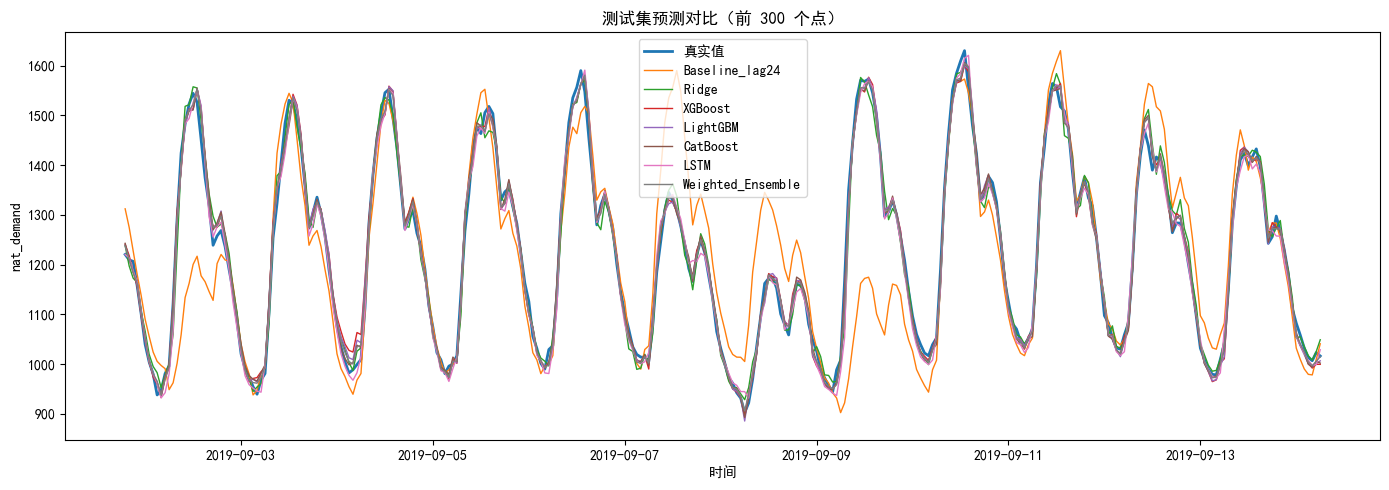

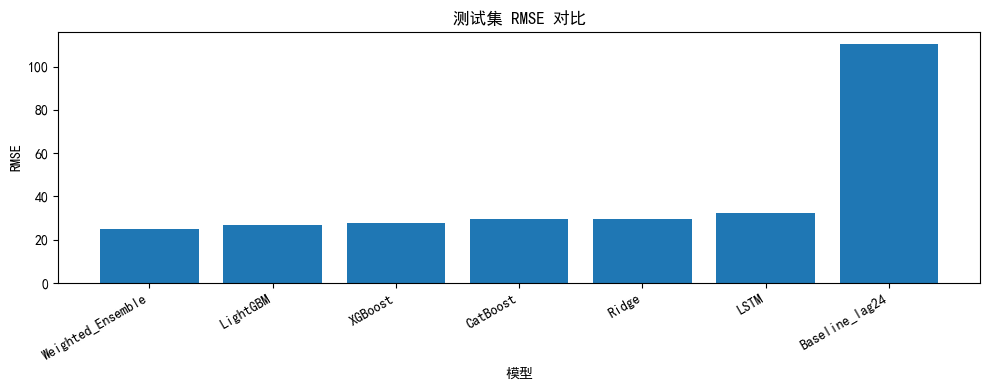

In [15]:
# ============================================================
# 14. 模型结果对比可视化
# ============================================================
# 这里展示测试集前 300 个点的真实值和预测值。
# 如果测试集很短，会自动显示全部测试集。

# 构建测试集预测结果表：第一列是真实值，后面是各模型预测。
y_test_full = pd.Series(y_test.values, index=test_index, name="True")
test_pred_df = pd.concat([y_test_full] + list(test_predictions.values()), axis=1).dropna()

# 如果存在融合模型，也加入对比。
if "Weighted_Ensemble" in test_predictions:
    # 避免重复添加：若已经在 concat 中存在则不处理。
    pass

plot_n = min(300, len(test_pred_df))
plot_df = test_pred_df.iloc[:plot_n]

plt.figure(figsize=(14, 5))
plt.plot(plot_df.index, plot_df["True"], label="真实值", linewidth=2)

for col in plot_df.columns:
    if col != "True":
        plt.plot(plot_df.index, plot_df[col], label=col, linewidth=1)

plt.title(f"测试集预测对比（前 {plot_n} 个点）")
plt.xlabel("时间")
plt.ylabel(TARGET_COL)
plt.legend()
plt.tight_layout()
plt.show()

# 模型 RMSE 柱状图，只展示测试集表现。
test_results = results_df[results_df["Split"] == "Test"].sort_values("RMSE")

plt.figure(figsize=(10, 4))
plt.bar(test_results["Model"], test_results["RMSE"])
plt.title("测试集 RMSE 对比")
plt.xlabel("模型")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 结果可视化解释

本节包含两类核心可视化：预测曲线对比图和测试集 RMSE 柱状图。

### 1. 测试集预测对比图

该图将测试集真实值与各模型预测值画在同一时间轴上。解读时重点观察：

- 预测曲线是否整体跟随真实负荷变化。
- 高峰和低谷位置是否预测准确。
- 某些模型是否存在系统性偏高或偏低。
- 在负荷快速上升或下降的时段，模型是否明显滞后。

如果某个模型曲线整体贴近真实值，且在峰谷处偏差较小，说明该模型具有较好的时序跟踪能力。

### 2. 测试集 RMSE 柱状图

该图用于直观比较各模型在测试集上的 RMSE。柱子越低，说明模型在测试集上的大误差越少或误差幅度越小。由于 RMSE 对大误差更敏感，因此该图可以作为判断最终模型的重要依据之一。

需要注意：若某模型 MAE 较低但 RMSE 较高，说明它在多数普通时段表现不错，但在部分极端时段误差较大。对于电力负荷预测，这种情况需要谨慎，因为高峰期或突变时段往往更具有业务意义。


当前误差分析模型：Weighted_Ensemble


,True,Pred,Error,AbsError
count,7182.000000,7182.000000,7182.000000,7182.000000
mean,1198.621817,1198.127723,0.494094,18.191180
std,184.634462,176.802600,24.952915,17.085872
min,816.354100,823.103289,-242.825464,0.008058
25%,1053.307475,1056.201748,-12.817482,6.194800
50%,1165.282150,1167.921444,0.504577,13.423218
75%,1324.718850,1320.121514,13.783908,25.019978
max,1754.882000,1645.836163,170.916839,242.825464


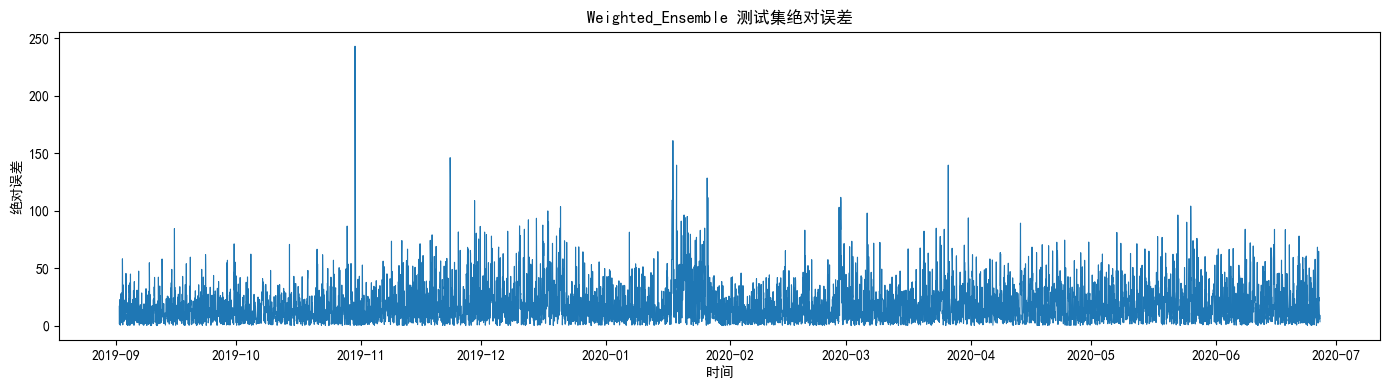

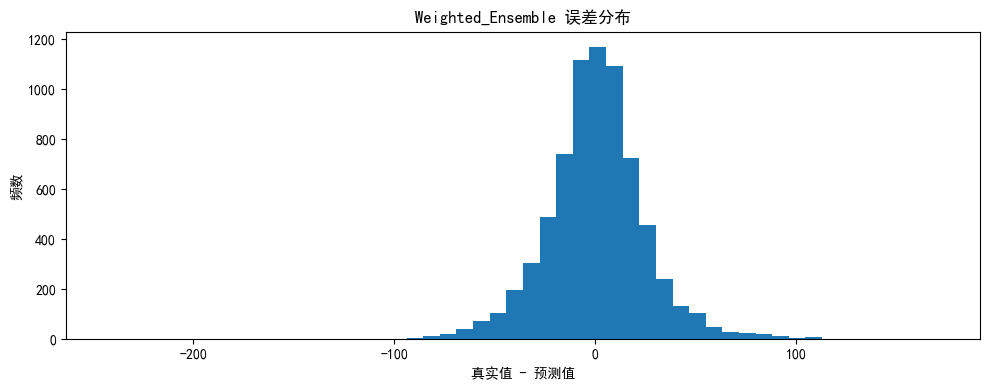

In [16]:
# ============================================================
# 15. 误差分析
# ============================================================
# 误差分析可以帮助判断模型在哪些时间段预测较差。
# 如果某些时间段误差明显增大，通常需要补充节假日、天气、特殊事件等特征。

if "Weighted_Ensemble" in test_predictions:
    analysis_model = "Weighted_Ensemble"
else:
    # 如果没有融合模型，则选择测试集 RMSE 最小的模型进行误差分析。
    analysis_model = (
        results_df[results_df["Split"] == "Test"]
        .sort_values("RMSE")
        .iloc[0]["Model"]
    )

error_df = pd.concat([
    pd.Series(y.values, index=time_index.values, name="True"),
    test_predictions[analysis_model].rename("Pred"),
], axis=1).dropna()

error_df["Error"] = error_df["True"] - error_df["Pred"]
error_df["AbsError"] = error_df["Error"].abs()

print(f"当前误差分析模型：{analysis_model}")
display(error_df[["True", "Pred", "Error", "AbsError"]].describe())

# 15.1 绝对误差时间序列
plt.figure(figsize=(14, 4))
plt.plot(error_df.index, error_df["AbsError"], linewidth=0.8)
plt.title(f"{analysis_model} 测试集绝对误差")
plt.xlabel("时间")
plt.ylabel("绝对误差")
plt.tight_layout()
plt.show()

# 15.2 误差分布直方图
plt.figure(figsize=(10, 4))
plt.hist(error_df["Error"], bins=50)
plt.title(f"{analysis_model} 误差分布")
plt.xlabel("真实值 - 预测值")
plt.ylabel("频数")
plt.tight_layout()
plt.show()

## 误差分析可视化解释

误差分析用于回答一个关键问题：模型错在哪里，而不仅仅是错了多少。

### 1. 绝对误差时间序列

该图展示测试集每个时间点的绝对误差。若某些时间段误差明显升高，说明模型在这些阶段预测困难。可能原因包括：节假日、天气突变、特殊事件、异常数据点或负荷结构变化。后续改进可以围绕这些高误差时段补充外部变量。

### 2. 误差分布直方图

误差定义为 `真实值 - 预测值`。如果误差分布集中在 0 附近，说明模型整体偏差较小；如果分布明显偏正，说明模型整体偏低估；如果分布明显偏负，说明模型整体偏高估。若误差分布长尾明显，说明模型在少数样本上存在较大的预测偏差。

误差分析的价值在于指导后续优化。例如，如果误差集中发生在某些小时，可以加强小时交互特征；如果误差集中在周末或节假日，则需要补充节假日类型变量。


使用 XGBoost 输出特征重要性。


,Feature,Importance
29,nat_demand_lag_1,0.474118
37,nat_demand_lag_168,0.259829
34,nat_demand_lag_24,0.035081
44,nat_demand_roll_max_12,0.031628
23,hour_sin,0.024827
15,hour,0.021810
30,nat_demand_lag_2,0.020588
58,nat_demand_diff_1,0.018622
24,hour_cos,0.017895
41,nat_demand_roll_min_6,0.014856


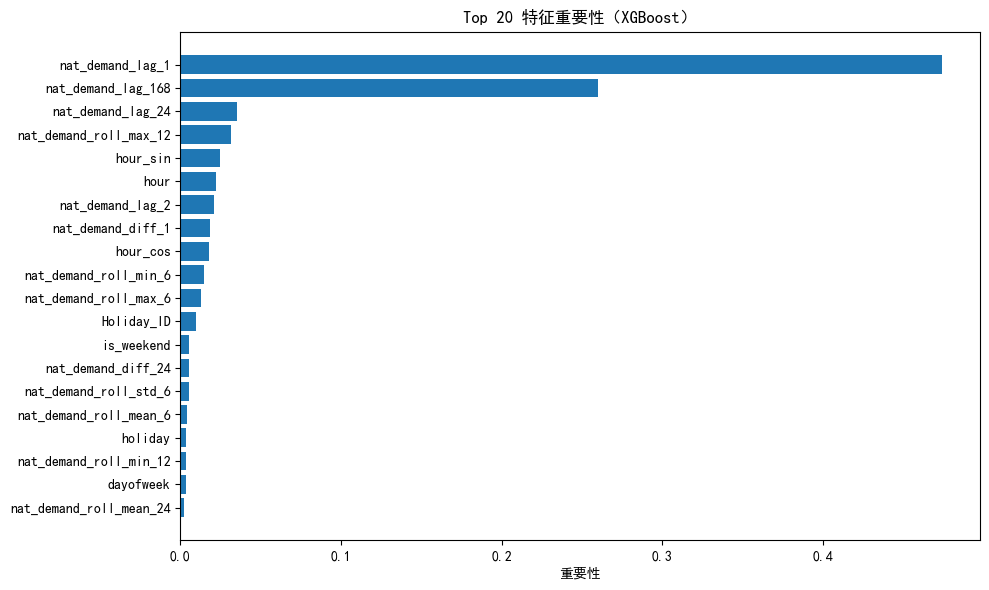

In [17]:
# ============================================================
# 16. 特征重要性分析
# ============================================================
# 树模型可以输出特征重要性，用于解释模型主要依赖哪些特征。
# 如果 XGBoost / LightGBM / CatBoost 均不可用，本单元会自动跳过。

importance_source = None
importance_values = None

if "xgb_model" in globals():
    importance_source = "XGBoost"
    importance_values = xgb_model.feature_importances_
elif "lgb_model" in globals():
    importance_source = "LightGBM"
    importance_values = lgb_model.feature_importances_
elif "cat_model" in globals():
    importance_source = "CatBoost"
    importance_values = cat_model.get_feature_importance()

if importance_values is None:
    print("当前没有可用的树模型，跳过特征重要性分析。")
else:
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": importance_values,
    }).sort_values("Importance", ascending=False)

    print(f"使用 {importance_source} 输出特征重要性。")
    display(importance_df.head(20))

    top_n = min(20, len(importance_df))
    top_features = importance_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title(f"Top {top_n} 特征重要性（{importance_source}）")
    plt.xlabel("重要性")
    plt.tight_layout()
    plt.show()

## 特征重要性解释

特征重要性图展示树模型在分裂过程中更依赖哪些特征。排名靠前的特征通常对模型预测贡献更大，例如滞后负荷、滚动均值、小时周期或星期周期特征。

需要注意，特征重要性反映的是模型使用特征的程度，不等同于严格因果关系。某个特征重要性高，说明它对预测有帮助，但不代表它一定是负荷变化的根本原因。实际解释时，应结合业务常识和误差分析共同判断。


In [ ]:
# ============================================================
# 17. 保存结果
# ============================================================
# 保存两个文件：
# 1. model_comparison_results.csv：各模型在验证集和测试集上的指标。
# 2. test_predictions.csv：测试集真实值和各模型预测值，方便后续写报告或画图。

results_output_path = Path("model_comparison_results.csv")
pred_output_path = Path("test_predictions.csv")

results_df.to_csv(results_output_path, index=False, encoding="utf-8-sig")
test_pred_df.to_csv(pred_output_path, encoding="utf-8-sig")

print(f"模型指标已保存：{results_output_path.resolve()}")
print(f"测试集预测已保存：{pred_output_path.resolve()}")

模型指标已保存：C:\Users\Liuxj\Desktop\电力预测\model_comparison_results8.csv
测试集预测已保存：C:\Users\Liuxj\Desktop\电力预测\test_predictions8.csv


## 输出结果说明

本节会保存两个结果文件：

1. `model_comparison_results3.csv`：包含各模型在验证集和测试集上的 MAE、RMSE、MAPE。
2. `test_predictions3.csv`：包含测试集真实值和各模型预测值，可用于后续单独绘图、误差分析。


